In [ ]:
import cfgrib
import xarray as xr
import pandas as pd
import numpy as np

# =========================
# 1️⃣ Load all datasets
# =========================
files = [
    "big_grid-timeseries_sel_vars_2023-2025_summer.grib",
    "big_grid-timeseries_sel_vars_2023-2025_springmoths.grib"
]

df_list = []

for f in files:
    datasets = cfgrib.open_datasets(f)
    ds_features = datasets[0]
    ds_tp       = datasets[1]

    # Features
    df_features = ds_features.to_dataframe().reset_index()
    df_features = df_features[["time","latitude","longitude","sp","tcc","u10","v10","t2m"]]
    df_features = df_features.rename(columns={"time":"valid_time"})

    # Precipitation
    tp = ds_tp["tp"]
    tp_deacc = tp.diff("time").clip(min=0)
    tp_df = tp.to_series().reset_index()
    tp_df["valid_time"] = tp_df["time"] + tp_df["step"]
    tp_df["tp_hourly"] = tp_df.groupby(["time","latitude","longitude"])["tp"].diff()
    tp_df["tp_hourly"] = tp_df["tp_hourly"].fillna(tp_df["tp"]).clip(lower=0)
    tp_df = tp_df[["valid_time","latitude","longitude","tp_hourly"]].sort_values("valid_time")
    
    # Merge features + tp
    df = pd.merge(df_features, tp_df, on=["valid_time","latitude","longitude"], how="inner")
    df = df.rename(columns={"tp_hourly":"tp"})
    
    df_list.append(df)



c:\Users\Tradeshop35\anaconda3\envs\appmlenv\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\Tradeshop35\anaconda3\envs\appmlenv\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


In [47]:
# =========================
# 2 Combine all periods
# =========================
df_all = pd.concat(df_list, ignore_index=True)

#  dedup 
df_all = df_all.drop_duplicates(subset=["valid_time","latitude","longitude"])
df_all = df_all.sort_values(["valid_time","latitude","longitude"]).reset_index(drop=True)

print(f"Grid points: {df_all[['latitude','longitude']].drop_duplicates().shape[0]}")
print(f"Total rows: {len(df_all)}")
print(f"Memory: {df_all.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# =========================
# 3️ Create time features
# =========================
df_all["hour"]      = df_all["valid_time"].dt.hour
df_all["dayofyear"] = df_all["valid_time"].dt.dayofyear
df_all["month"]     = df_all["valid_time"].dt.month
df_all["sin_doy"] = np.sin(2*np.pi*df_all["dayofyear"]/365)
df_all["cos_doy"] = np.cos(2*np.pi*df_all["dayofyear"]/365)



Grid points: 1281
Total rows: 19737648
Memory: 0.95 GB


In [ ]:
# =========================
# 4️ Lags & rolling
# =========================
lags = [1, 3, 6, 12, 24, 48, 72]
vars_to_lag = ["t2m","sp","tcc","u10","v10","tp"]

for var in vars_to_lag:
    for lag in lags:
        df_all[f"{var}_lag{lag}"] = df_all.groupby(["latitude","longitude"])[var].shift(lag)

for var in vars_to_lag:
    df_all[f"{var}_roll24_mean"] = df_all.groupby(["latitude","longitude"])[var].transform(lambda x: x.rolling(24).mean())



In [ ]:
# =========================
# 5️ 1h ahead target
# =========================

df_all["tp_target"] = df_all.groupby(["latitude","longitude"])["tp"].shift(-1)
df_all = df_all.dropna().copy()  # drop rows with NaNs due to lags/rolling/target

# =========================
# 6️ Create X, y, weights
# =========================
y_all = np.log1p(df_all["tp_target"])
X_all = df_all.drop(columns=["valid_time", "tp_target"])
X_all = X_all[[col for col in X_all.columns if not col.startswith("tp_target")]]

weights_all = 1 + 100*np.expm1(y_all)

# 5️ 1h ahead target


# =========================
# 7️ Train / Val / Test split
# =========================
n = len(df_all)
train_end = int(n*0.70)
val_end   = int(n*0.85)

X_train_full = X_all.iloc[:train_end]
y_train_full = y_all.iloc[:train_end]
weights_full = weights_all.iloc[:train_end]

X_val   = X_all.iloc[train_end:val_end]
y_val   = y_all.iloc[train_end:val_end]

X_test  = X_all.iloc[val_end:]
y_test  = y_all.iloc[val_end:]

time_train = df_all["valid_time"].iloc[:train_end]
time_val   = df_all["valid_time"].iloc[train_end:val_end]
time_test  = df_all["valid_time"].iloc[val_end:]

# =========================
#  Undersampling (μόνο στο train)
# =========================
rain_mask = np.expm1(y_train_full) >= 0.0001
dry_mask  = ~rain_mask

rain_idx = np.where(rain_mask)[0]
dry_idx  = np.where(dry_mask)[0]

# keep all the rain + 3x dry samples
np.random.seed(42)
keep_dry = np.random.choice(dry_idx, size=len(rain_idx)*10, replace=False)
keep_idx = np.sort(np.concatenate([rain_idx, keep_dry]))

X_train = X_train_full.iloc[keep_idx]
y_train = y_train_full.iloc[keep_idx]
weights_train = weights_full.iloc[keep_idx]

print(f"Original train size:  {len(X_train_full)}")
print(f"Balanced train size:  {len(X_train)}")
print(f"Rain %: {(np.expm1(y_train)>=0.0001).mean()*100:.1f}%")

Original train size:  13750894
Balanced train size:  10815376
Rain %: 9.1%


In [20]:
!conda install -c conda-forge cartopy -y

Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\Tradeshop35\anaconda3\envs\appmlenv

  added / updated specs:
    - cartopy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _libavif_api-1.4.2         |       h57928b3_0          10 KB  conda-forge
    aom-3.9.1                  |       he0c23c2_0         1.9 MB  conda-forge
    ca-certificates-2026.5.20  |       h4c7d964_0         127 KB  conda-forge
    cairo-1.18.4               |       he9e932c_0         637 KB
    cartopy-0.25.0             |  py312h42c1672_0         1.5 MB
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    contourpy-1.3.3            |  py312h214f63a_0        11.3 MB
    cycler-0.12.1              |     pyhcf101f3_2          14 KB  conda-forge
    dav1d-1.2.1                |       hcfcfb64_0         604 KB  conda-forge
    fontconfig-2.17.1



==> WARNING: A newer version of conda exists. <==
  current version: 23.9.0
  latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.5.2


WARNING conda.gateways.disk.delete:unlink_or_rename_to_trash(188): Could not remove or rename C:\Users\Tradeshop35\anaconda3\envs\appmlenv\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSans.ttf.  Please remove this file manually (you may need to reboot to free file handles)


In [50]:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print(cartopy.__version__)

0.25.0


In [51]:
from xgboost import XGBRegressor

weights_train = 1 + 1000*np.expm1(y_train)

model_grid = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_grid.fit(X_train, y_train, sample_weight=weights_train)
print("Model training done!")

Model training done!


In [52]:
def plot_precip_map_comparison_test(model, X_test, y_test, time_test, df_all, target_datetime):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    target_dt = pd.Timestamp(target_datetime)

    df_plot = X_test.copy()
    df_plot["valid_time"] = pd.to_datetime(time_test).values
    df_plot["tp_target"] = y_test.values

    # παίρνουμε lat/lon από df_all με βάση τα ίδια index του X_test
    df_plot["latitude"] = df_all.loc[X_test.index, "latitude"].values
    df_plot["longitude"] = df_all.loc[X_test.index, "longitude"].values

    mask = df_plot["valid_time"] == target_dt

    if mask.sum() == 0:
        print("No test data found for this time:", target_dt)
        return

    X_map = df_plot.loc[mask, X_test.columns]

    pred_log = model.predict(X_map)
    pred_tp = np.expm1(pred_log).clip(0)
    true_tp = np.expm1(df_plot.loc[mask, "tp_target"].values).clip(0)

    lats = df_plot.loc[mask, "latitude"].values
    lons = df_plot.loc[mask, "longitude"].values

    lat_unique = np.sort(np.unique(lats))[::-1]
    lon_unique = np.sort(np.unique(lons))

    def make_grid(values):
        grid = np.zeros((len(lat_unique), len(lon_unique)))
        for i, lat in enumerate(lat_unique):
            for j, lon in enumerate(lon_unique):
                point_mask = (lats == lat) & (lons == lon)
                if point_mask.any():
                    grid[i, j] = values[point_mask][0]
        return grid

    input_time = target_dt
    forecast_time = input_time + pd.Timedelta(hours=1)

    print("Input time:   ", input_time)
    print("Forecast time:", forecast_time)
    print("This plot uses TEST data only.")

    fig, axes = plt.subplots(
        1, 2, figsize=(16, 6),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    vmin = 0
    vmax = max(pred_tp.max(), true_tp.max())

    for ax, values, title in zip(axes, [true_tp, pred_tp], ["True", "Predicted"]):
        grid = make_grid(values)

        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                          color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

        im = ax.contourf(
            lon_unique, lat_unique, grid,
            cmap="Blues", levels=20,
            vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(),
            alpha=0.8
        )

        ax.scatter(
            lons, lats, c="black", s=2, alpha=0.15,
            zorder=5, transform=ccrs.PlateCarree()
        )

        ax.set_extent(
            [lon_unique.min() - 0.5, lon_unique.max() + 0.5,
             lat_unique.min() - 0.5, lat_unique.max() + 0.5],
            crs=ccrs.PlateCarree()
        )

        ax.set_title(
            f"{title} Precipitation\nForecast valid: {forecast_time}"
        )

        plt.colorbar(im, ax=ax, label="Precipitation (m)")

    plt.tight_layout()
    plt.show()

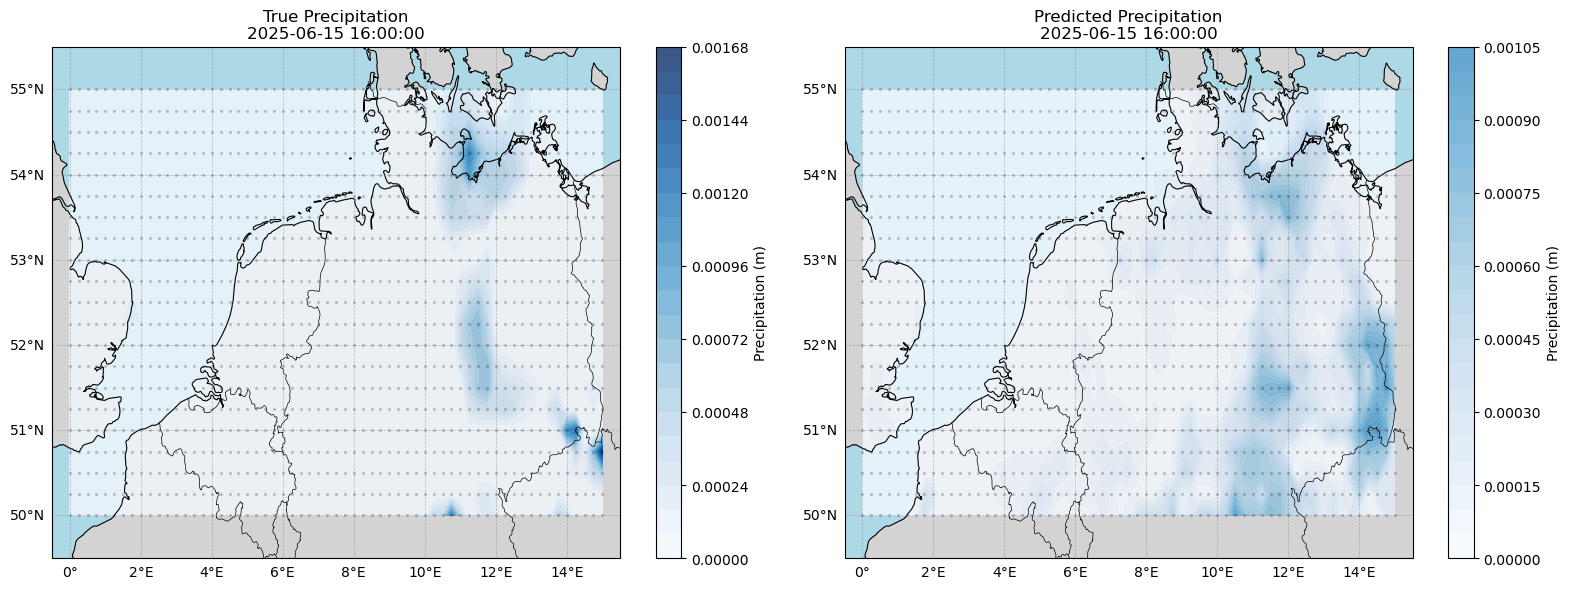

In [54]:
target_time = "2025-06-15 16:00:00"

plot_precip_map_comparison(
    model_grid,
    X_all,
    df_all,
    target_time
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import HTML
import pandas as pd
import numpy as np

def plot_precip_movie(model, X, df_full, time_series, output_file="precip_24h.gif"):
    
    # making df_plot ONCE out of loop
    df_plot = X.copy()
    df_plot["valid_time"] = df_full.loc[X.index, "valid_time"].values
    df_plot["latitude"]   = df_full.loc[X.index, "latitude"].values
    df_plot["longitude"]  = df_full.loc[X.index, "longitude"].values
    df_plot["tp_target"]  = df_full.loc[X.index, "tp_target"].values

    frames = []
    
    for t in time_series:
        target_dt = pd.Timestamp(t)
        mask = df_plot["valid_time"] == target_dt
        if mask.sum() == 0:
            continue

        X_map    = df_plot.loc[mask, X.columns]
        pred_log = model.predict(X_map)
        pred_tp  = np.expm1(pred_log).clip(0)
        true_tp  = df_plot.loc[mask, "tp_target"].values
        lats     = df_plot.loc[mask, "latitude"].values
        lons     = df_plot.loc[mask, "longitude"].values

        lat_unique = np.sort(np.unique(lats))[::-1]
        lon_unique = np.sort(np.unique(lons))

        def make_grid(values):
            grid = np.zeros((len(lat_unique), len(lon_unique)))
            for i, lat in enumerate(lat_unique):
                for j, lon in enumerate(lon_unique):
                    pm = (lats == lat) & (lons == lon)
                    if pm.any():
                        grid[i, j] = values[pm][0]
            return grid

        frames.append({
            "time": target_dt,
            "true": make_grid(true_tp),
            "pred": make_grid(pred_tp),
            "lats": lat_unique,
            "lons": lon_unique,
        })

    if not frames:
        print("No frames found!")
        return

    vmax = max(max(f["true"].max(), f["pred"].max()) for f in frames)
    vmax = max(vmax, 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             subplot_kw={"projection": ccrs.PlateCarree()})

    def draw_frame(i):
        for ax in axes:
            ax.clear()
            ax.add_feature(cfeature.LAND, facecolor="lightgray")
            ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
            ax.add_feature(cfeature.BORDERS, linewidth=0.5)
            
            # Gridlines με labels
            gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                              color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            
            pad = 0.5
            ax.set_extent([frames[i]["lons"].min()-pad, frames[i]["lons"].max()+pad,
                           frames[i]["lats"].min()-pad, frames[i]["lats"].max()+pad],
                          crs=ccrs.PlateCarree())

        im0 = axes[0].contourf(frames[i]["lons"], frames[i]["lats"], frames[i]["true"],
                                cmap="Blues", levels=20, vmin=0, vmax=vmax,
                                transform=ccrs.PlateCarree(), alpha=0.8)
        im1 = axes[1].contourf(frames[i]["lons"], frames[i]["lats"], frames[i]["pred"],
                                cmap="Blues", levels=20, vmin=0, vmax=vmax,
                                transform=ccrs.PlateCarree(), alpha=0.8)

        axes[0].set_title(f"True Precipitation\n{frames[i]['time']}")
        axes[1].set_title(f"Predicted Precipitation\n{frames[i]['time']}")

        return [im0, im1]

    ani = animation.FuncAnimation(fig, draw_frame, frames=len(frames), interval=500)
    ani.save(output_file, writer="pillow", fps=2)
    plt.close()
    print(f"Saved: {output_file}")



In [ ]:
# July 2025 only 17:00
time_july_17h = time_test[
    (time_test.dt.month == 9) & 
    (time_test.dt.year == 2025) & 
    (time_test.dt.hour == 17)
].unique()

plot_precip_movie(model_grid, X_test, df_all, time_july_17h, "precip_september2025_17h.gif")

Saved: precip_september2025_17h.gif


In [ ]:
# Run for 24 hours of test set
time_24h = time_test.unique()[:24]
plot_precip_movie(model_grid, X_all, df_all, time_24h, "precip_24h.gif")

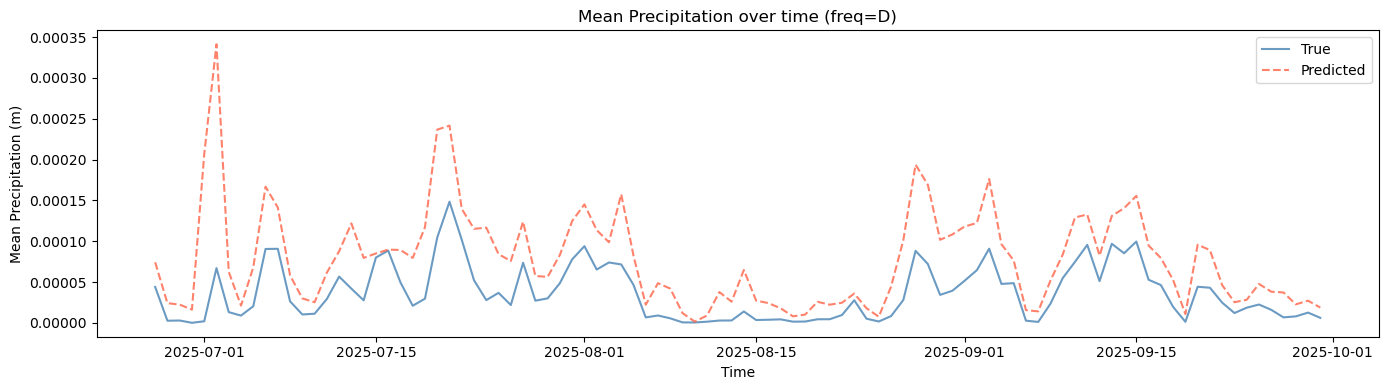

C:\Users\Tradeshop35\AppData\Local\Temp\ipykernel_18728\3880177823.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true_mean = df_plot["tp_true"].resample(freq).mean()
C:\Users\Tradeshop35\AppData\Local\Temp\ipykernel_18728\3880177823.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pred_mean = df_plot["tp_pred"].resample(freq).mean()


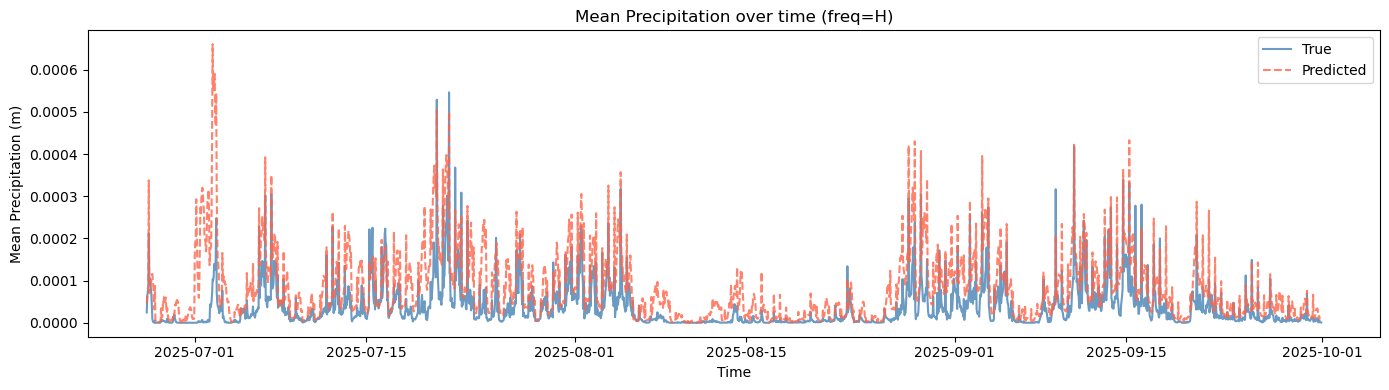

In [ ]:
def plot_precip_timeseries(model, X, df_full, time_series, freq="D"):
    """
    freq: "H" = ανά ώρα, "D" = ανά μέρα, "ME" = ανά μήνα
    """
    df_plot = X.copy()
    df_plot["valid_time"] = df_full.loc[X.index, "valid_time"].values
    df_plot["tp_target"]  = df_full.loc[X.index, "tp_target"].values

    pred_log = model.predict(X)
    df_plot["tp_pred"] = np.expm1(pred_log).clip(0)
    df_plot["tp_true"] = np.expm1(df_plot["tp_target"]).clip(0)

    df_plot = df_plot.set_index("valid_time")

    true_mean = df_plot["tp_true"].resample(freq).mean()
    pred_mean = df_plot["tp_pred"].resample(freq).mean()

    plt.figure(figsize=(14, 4))
    plt.plot(true_mean.index, true_mean.values, label="True",      color="steelblue", alpha=0.8)
    plt.plot(pred_mean.index, pred_mean.values, label="Predicted", color="tomato",    alpha=0.8, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Mean Precipitation (m)")
    plt.title(f"Mean Precipitation over time (freq={freq})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Every day of test set
plot_precip_timeseries(model_grid, X_test, df_all, time_test, freq="D")

# hourly (daily curcly)
plot_precip_timeseries(model_grid, X_test, df_all, time_test, freq="H")

In [59]:
def plot_precip_daily_at_hour(model, X, df_full, hour=17, split_label="Test"):
    df_plot = X.copy()
    df_plot["valid_time"] = df_full.loc[X.index, "valid_time"].values
    df_plot["tp_target"]  = df_full.loc[X.index, "tp_target"].values

    pred_log = model.predict(X)
    df_plot["tp_pred"] = np.expm1(pred_log).clip(0)
    df_plot["tp_true"] = np.expm1(df_plot["tp_target"]).clip(0)

    mask = df_plot["valid_time"].dt.hour == hour
    df_hour = (
        df_plot[mask]
        .groupby("valid_time")[["tp_true", "tp_pred"]]
        .mean()
        .sort_index()
    )

    if df_hour.empty:
        print(f"No data found for hour {hour:02d}:00")
        return

    date_from = df_hour.index.min().strftime("%Y-%m-%d")
    date_to   = df_hour.index.max().strftime("%Y-%m-%d")

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(df_hour.index, df_hour["tp_true"], label="True",
            color="blue", linewidth=1.5)
    ax.plot(df_hour.index, df_hour["tp_pred"], label="Predicted",
            color="orange", linewidth=1.5)
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean Precipitation (m)")
    ax.set_title(f"[{split_label} set]  Daily precipitation @ {hour:02d}:00  |  {date_from} → {date_to}")
    ax.legend()
    plt.tight_layout()
    plt.show()

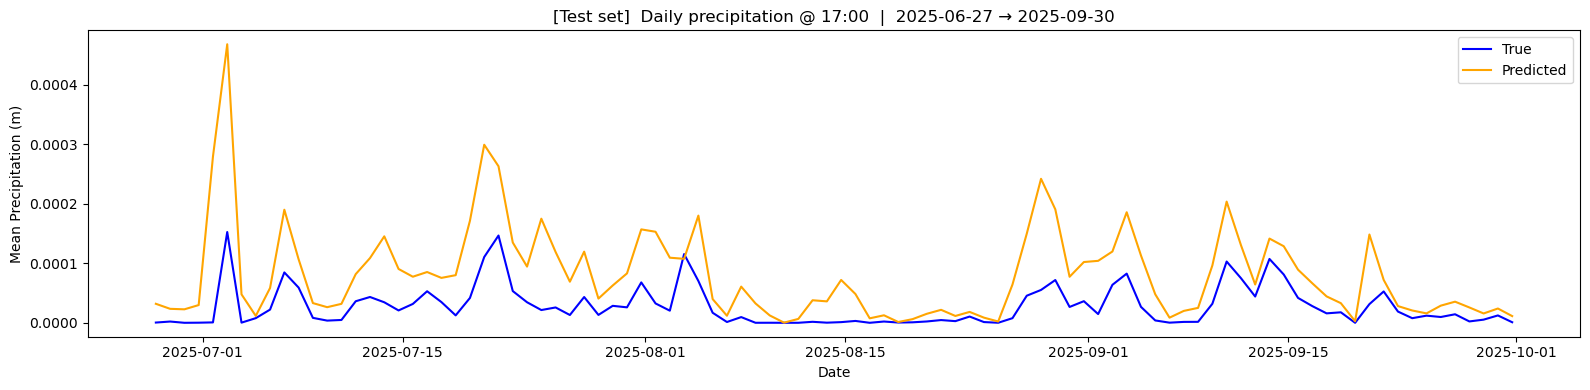

In [60]:
plot_precip_daily_at_hour(
    model_grid, X_test, df_all,
    hour=17,
    split_label="Test"
)

In [61]:
def plot_precip_timeseries(model, X, df_full, freq="D", split_label="Test"):
    """
    freq: "H" = hourly, "D" = daily, "ME" = monthly
    """
    df_plot = X.copy()
    df_plot["valid_time"] = df_full.loc[X.index, "valid_time"].values
    df_plot["tp_target"]  = df_full.loc[X.index, "tp_target"].values

    pred_log = model.predict(X)
    df_plot["tp_pred"] = np.expm1(pred_log).clip(0)
    df_plot["tp_true"] = np.expm1(df_plot["tp_target"]).clip(0)

    df_plot = df_plot.set_index("valid_time").sort_index()

    true_mean = df_plot["tp_true"].resample(freq).mean()
    pred_mean = df_plot["tp_pred"].resample(freq).mean()

    date_from = df_plot.index.min().strftime("%Y-%m-%d")
    date_to   = df_plot.index.max().strftime("%Y-%m-%d")
    freq_label = {"H": "Hourly", "D": "Daily", "ME": "Monthly"}.get(freq, freq)

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(true_mean.index, true_mean.values, label="True",
            color="blue", linewidth=1.5)
    ax.plot(pred_mean.index, pred_mean.values, label="Predicted",
            color="orange", linewidth=1.5)
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean Precipitation (m)")
    ax.set_title(f"[{split_label} set]  {freq_label} mean precipitation  |  {date_from} → {date_to}")
    ax.legend()
    plt.tight_layout()
    plt.show()

C:\Users\Tradeshop35\AppData\Local\Temp\ipykernel_18728\1268060058.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true_mean = df_plot["tp_true"].resample(freq).mean()
C:\Users\Tradeshop35\AppData\Local\Temp\ipykernel_18728\1268060058.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pred_mean = df_plot["tp_pred"].resample(freq).mean()


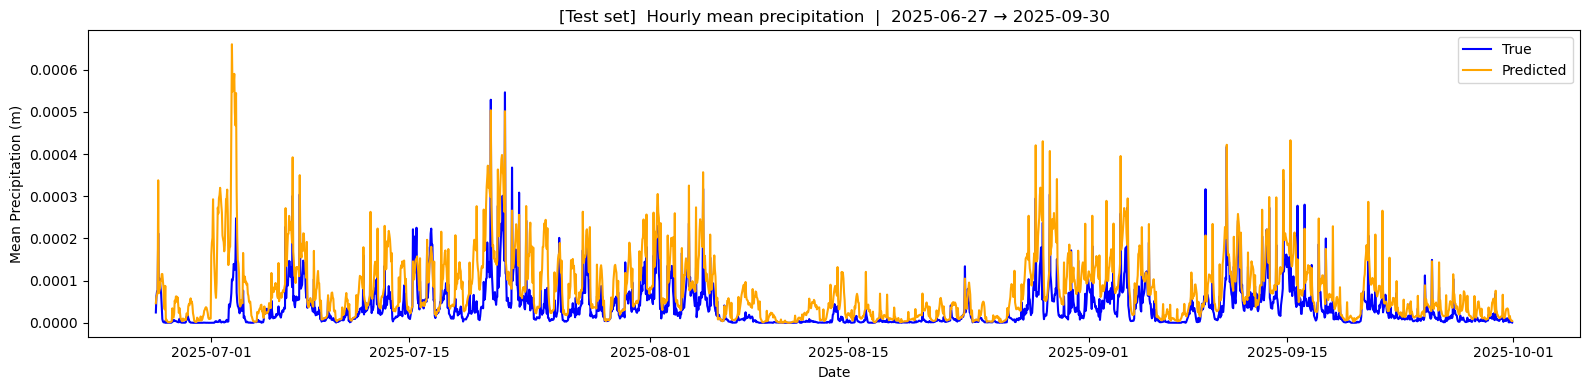

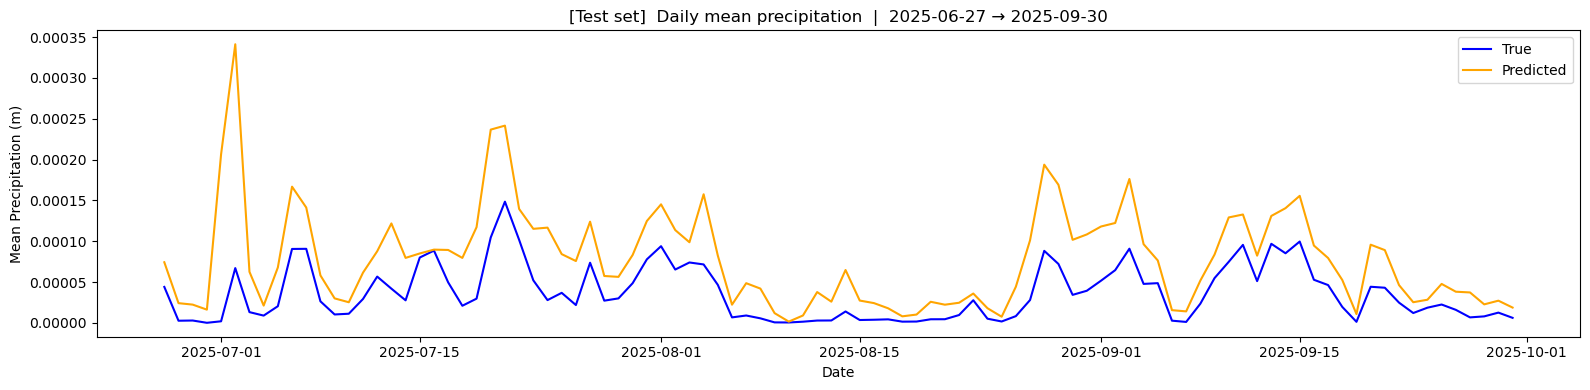

In [ ]:
# hourly
plot_precip_timeseries(model_grid, X_test, df_all, freq="H", split_label="Test")

# daily
plot_precip_timeseries(model_grid, X_test, df_all, freq="D", split_label="Test")

In [35]:
# =========================
# METRICS
# =========================
from sklearn.metrics import mean_squared_error, mean_absolute_error
def compute_metrics(true_log, pred_log, name, threshold=0.0001):
    true = np.expm1(true_log)
    pred = np.expm1(pred_log).clip(0)

    # Regression metrics
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    bias = (pred - true).mean()
    baseline_rmse = np.sqrt(mean_squared_error(true, np.zeros_like(true)))
    skill = 1 - rmse / baseline_rmse

    # Detection metrics (binary: rain or no rain)
    obs_rain  = true >= threshold
    pred_rain = pred >= threshold

    hits   = (obs_rain & pred_rain).sum()
    misses = (obs_rain & ~pred_rain).sum()
    fa     = (~obs_rain & pred_rain).sum()

    pod = hits / (hits + misses + 1e-10)  # Probability of Detection
    far = fa   / (hits + fa + 1e-10)      # False Alarm Rate
    csi = hits / (hits + misses + fa + 1e-10)  # Critical Success Index

    print(f"\n{'='*30}")
    print(f"  {name}")
    print(f"{'='*30}")
    print(f"  RMSE:  {rmse:.6f} m")
    print(f"  MAE:   {mae:.6f} m")
    print(f"  Bias:  {bias:.6f} m  ({'overpredict' if bias>0 else 'underpredict'})")
    print(f"  Skill: {skill:.3f}  (1=perfect, 0=same as predicting 0)")
    print(f"  POD:   {pod:.3f}  (1=perfect)")
    print(f"  FAR:   {far:.3f}  (0=perfect)")
    print(f"  CSI:   {csi:.3f}  (1=perfect)")



In [63]:
pred_val_log  = model_grid.predict(X_val)
pred_test_log = model_grid.predict(X_test)

compute_metrics(y_val,  pred_val_log,  "Validation")
compute_metrics(y_test, pred_test_log, "Test")


  Validation
  RMSE:  0.000148 m
  MAE:   0.000047 m
  Bias:  0.000021 m  (overpredict)
  Skill: 0.042  (1=perfect, 0=same as predicting 0)
  POD:   0.712  (1=perfect)
  FAR:   0.756  (0=perfect)
  CSI:   0.222  (1=perfect)

  Test
  RMSE:  0.000197 m
  MAE:   0.000079 m
  Bias:  0.000042 m  (overpredict)
  Skill: -0.014  (1=perfect, 0=same as predicting 0)
  POD:   0.746  (1=perfect)
  FAR:   0.781  (0=perfect)
  CSI:   0.204  (1=perfect)


In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(true_log, pred_log, name, threshold=0.0001):
    true = np.expm1(true_log)
    pred = np.expm1(pred_log).clip(0)

    obs_rain  = (true >= threshold).astype(int)
    pred_rain = (pred >= threshold).astype(int)

    cm = confusion_matrix(obs_rain, pred_rain)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Rain", "Rain"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name} (threshold={threshold} m)")
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_roc_curve(true_log, pred_log, name, threshold=0.0005):
    true = np.expm1(true_log)
    pred = np.expm1(pred_log).clip(0)

    obs_rain = (true >= threshold).astype(int)  

    fpr, tpr, _ = roc_curve(obs_rain, pred)     
    auc = roc_auc_score(obs_rain, pred)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], "k--", alpha=0.4)
    plt.xlabel("False Alarm Rate")
    plt.ylabel("Probability of Detection")
    plt.title(f"ROC Curve — {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

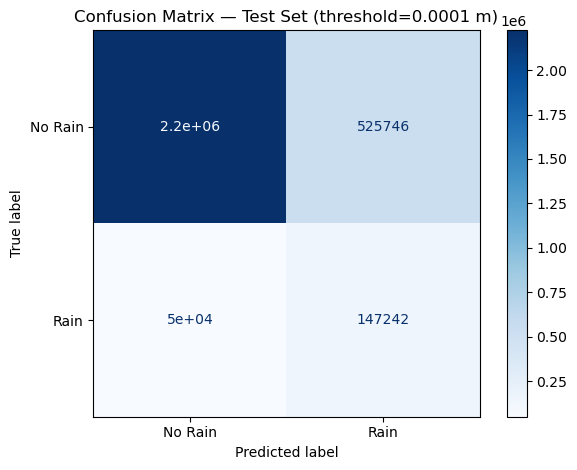

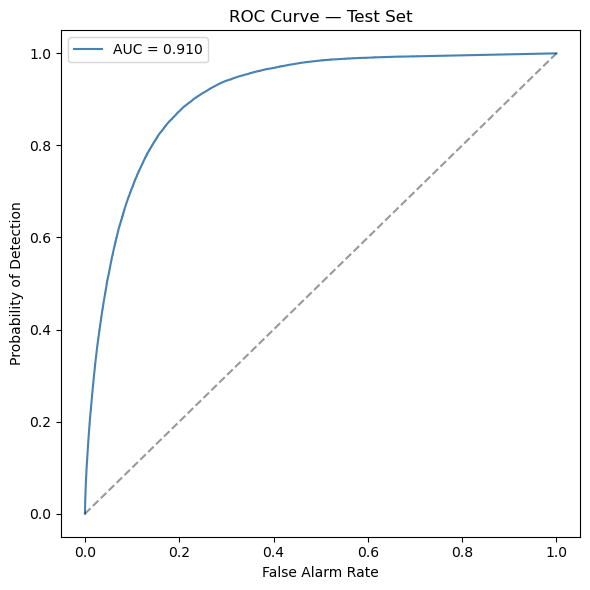

In [69]:
pred_log_test = model_grid.predict(X_test)

plot_confusion_matrix(y_test, pred_log_test, name="Test Set")
plot_roc_curve(y_test, pred_log_test, name="Test Set")

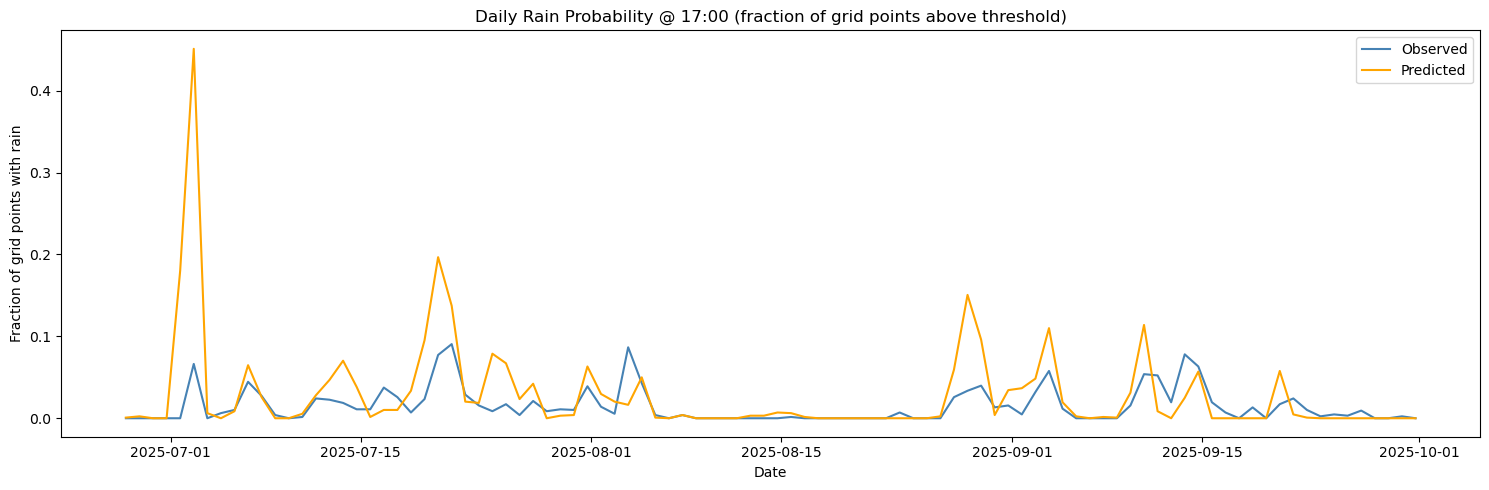

In [70]:
def daily_rain_probability(model, X, df_full, time_series, threshold=0.0001):
    """
    For each day at 17:00, computes:
    - % of grid points predicting rain
    - % of grid points that actually rained
    """
    df_plot = X.copy()
    df_plot["valid_time"] = df_full.loc[X.index, "valid_time"].values
    df_plot["latitude"]   = df_full.loc[X.index, "latitude"].values
    df_plot["longitude"]  = df_full.loc[X.index, "longitude"].values
    df_plot["tp_target"]  = df_full.loc[X.index, "tp_target"].values

    results = []

    for t in time_series:
        target_dt = pd.Timestamp(t)
        mask = (df_plot["valid_time"] == target_dt)
        if mask.sum() == 0:
            continue

        X_map    = df_plot.loc[mask, X.columns]
        pred_log = model.predict(X_map)
        pred_tp  = np.expm1(pred_log).clip(0)
        true_tp  = df_plot.loc[mask, "tp_target"].values

        prob_pred = (pred_tp >= threshold).mean()
        prob_true = (true_tp >= threshold).mean()

        results.append({
            "datetime": target_dt,
            "prob_predicted": prob_pred,
            "prob_observed": prob_true
        })

    return pd.DataFrame(results)

# Run for all 17:00 timestamps in test set
times_17 = time_test[time_test.dt.hour == 17].unique()

prob_df = daily_rain_probability(model_grid, X_all, df_all, times_17, threshold=0.0005)

# Plot
plt.figure(figsize=(15, 5))
plt.plot(prob_df["datetime"], prob_df["prob_observed"],  label="Observed",  color="steelblue")
plt.plot(prob_df["datetime"], prob_df["prob_predicted"], label="Predicted", color="orange")
plt.xlabel("Date")
plt.ylabel("Fraction of grid points with rain")
plt.title("Daily Rain Probability @ 17:00 (fraction of grid points above threshold)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [4, 5, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=15,          
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,          
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train, sample_weight=weights_train)

print("Best params:", random_search.best_params_)
best_model = random_search.best_estimator_

In [ ]:
# TRAIN FINAL MODEL
# =========================
best_params = study.best_params.copy()
weight_scale = best_params.pop("weight_scale")
best_params.pop("early_stopping_rounds", None)  # remove before final fit
weights_best = 1 + weight_scale * np.expm1(y_train)

best_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train, sample_weight=weights_best)

joblib.dump(best_model, "best_model.pkl")
print("Model saved!")

